Importando as bibliotecas e módulos necessários: 

In [1]:
#!pip install matplotlib
#!pip install pyarrow
import os
import pandas as pd
import numpy as np
import sys
import gc
import matplotlib.pyplot as plt

Carregando a base a ser utilizada:

In [2]:
df_final = pd.read_parquet(r"C:\Users\emill\Downloads\TCC\processed\BASE_UNIF.parquet", engine="pyarrow")

### Análise Exploratória dos dados
Esta seção concentra-se na discussão das principais descobertas da análise exploratória de dados (AED). Em particular, três questões de AED foram formuladas e investigadas com o uso de resumos numéricos (medidas de tendência central, medidas de dispersão e correlação). Informações adicionais também puderam ser obtidas a partir de suas respectivas visualizações.

#### 1. Quantidade de alunos por ano
O objetivo é comparar a participação entre os anos

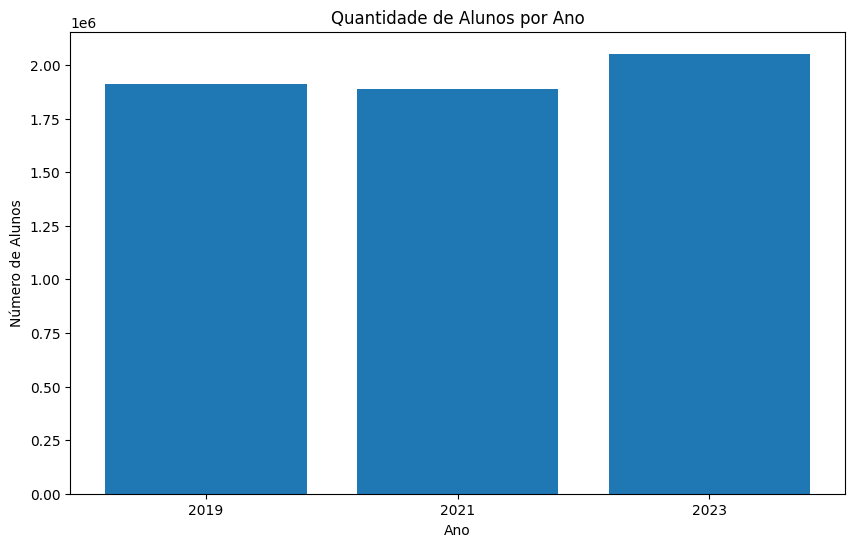

In [3]:
quantidade = (
    df_final["ANO"]
    .value_counts()
    .sort_index()
)

plt.figure(figsize=(10,6))

plt.bar(
    quantidade.index.astype(str),
    quantidade.values
)

plt.title("Quantidade de Alunos por Ano")
plt.xlabel("Ano")
plt.ylabel("Número de Alunos")

plt.show()

#### 2. Evolução da proficiência
O objetivo é comparar a evolução da proficiência entre os anos

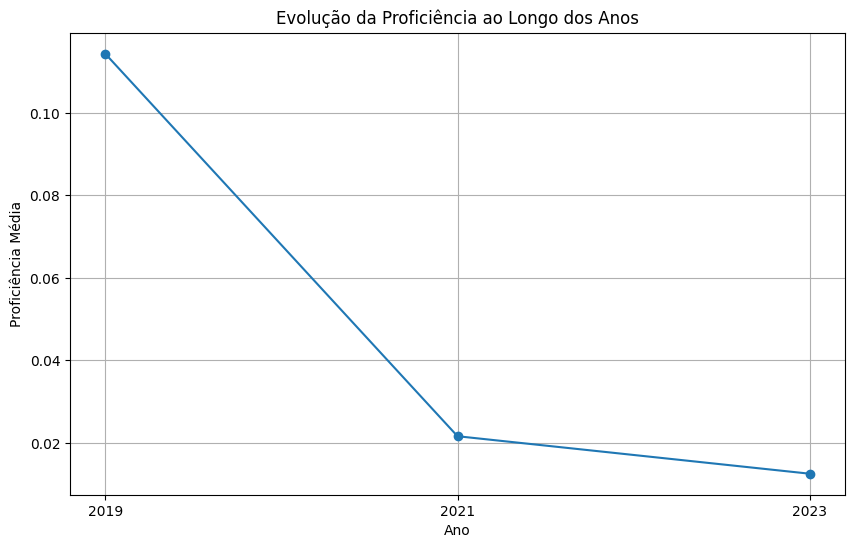

In [4]:
df_final["PROFICIENCIA_MT"] = pd.to_numeric(
    df_final["PROFICIENCIA_MT"],
    errors="coerce"
)

media_prof = df_final.groupby("ANO")["PROFICIENCIA_MT"].mean()

media_prof.plot(
    kind="line",
    marker="o",
    figsize=(10,6)
)

plt.xticks(media_prof.index)

plt.title("Evolução da Proficiência ao Longo dos Anos")
plt.xlabel("Ano")
plt.ylabel("Proficiência Média")

plt.grid(True)

plt.show()

#### 3. Participação x Proficiência
O objetivo é analisar se mudanças na proficiência podem estar relacionadas ao aumento/redução da participação

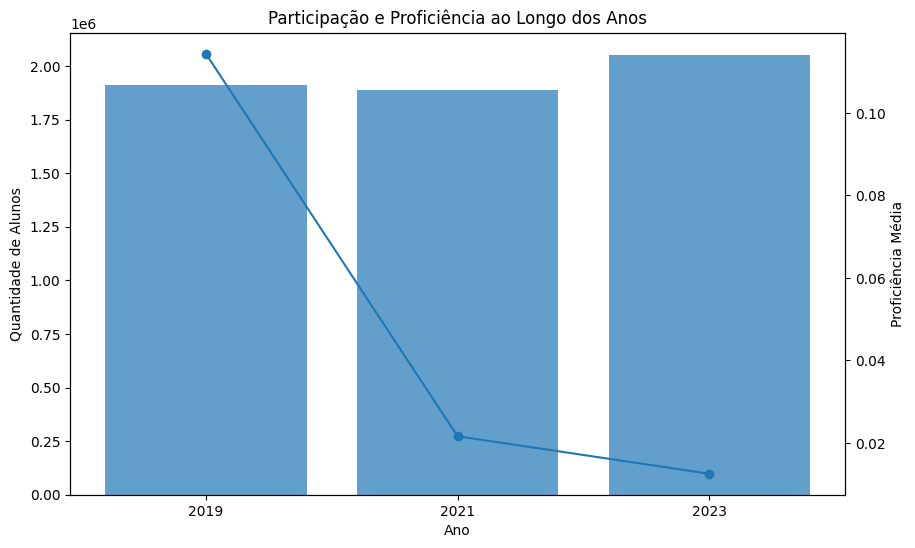

In [5]:
participacao = df_final.groupby("ANO")["ID_ALUNO"].nunique()

proficiencia = df_final.groupby("ANO")["PROFICIENCIA_MT"].mean()

fig, ax1 = plt.subplots(figsize=(10,6))

# ----- participação -----
ax1.bar(
    participacao.index.astype(str),
    participacao.values,
    alpha=0.7
)

ax1.set_xlabel("Ano")
ax1.set_ylabel("Quantidade de Alunos")

# ----- proficiência -----
ax2 = ax1.twinx()

ax2.plot(
    proficiencia.index.astype(str),
    proficiencia.values,
    marker="o"
)

ax2.set_ylabel("Proficiência Média")

plt.title("Participação e Proficiência ao Longo dos Anos")

plt.show()

#### 4. Bloxpot proficiência por ano 
O objetivo é analisar mediana, quartis, dispersão e outliers

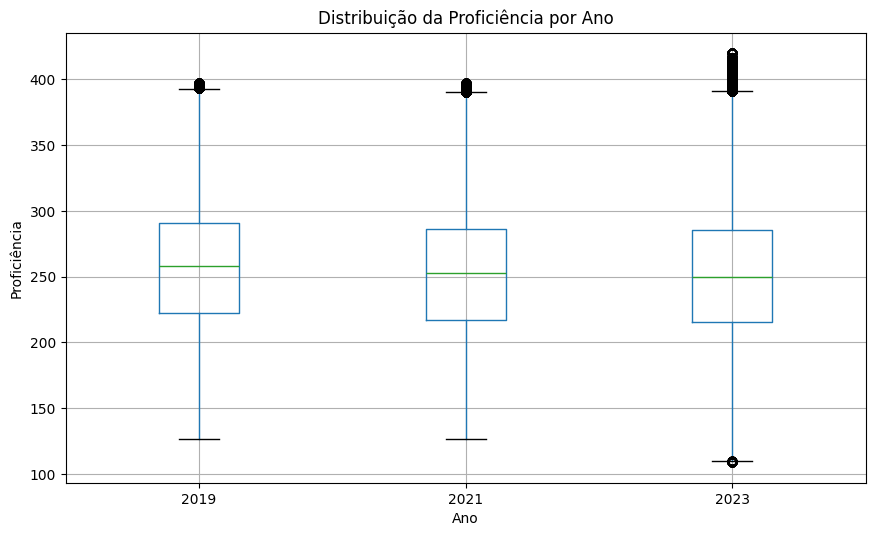

In [6]:
df_final.boxplot(
    column="PROFICIENCIA_SAEB",
    by="ANO",
    figsize=(10,6)
)

plt.title("Distribuição da Proficiência por Ano")
plt.suptitle("") 

plt.xlabel("Ano")
plt.ylabel("Proficiência")

plt.show()

#### 5. Distribuição das Variáveis
O objetivo dessa fase foi comparar as respostas para as variáveis categóricas entre os anos

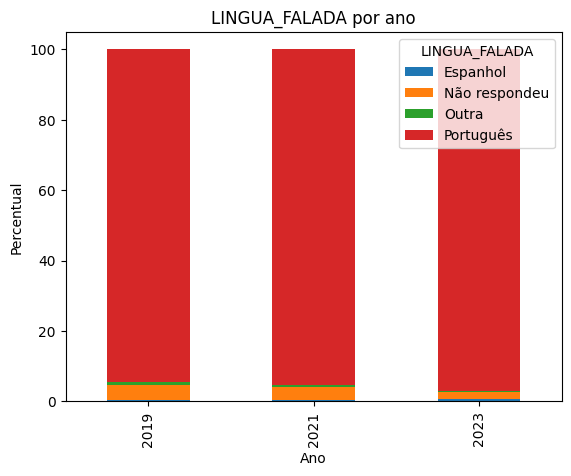

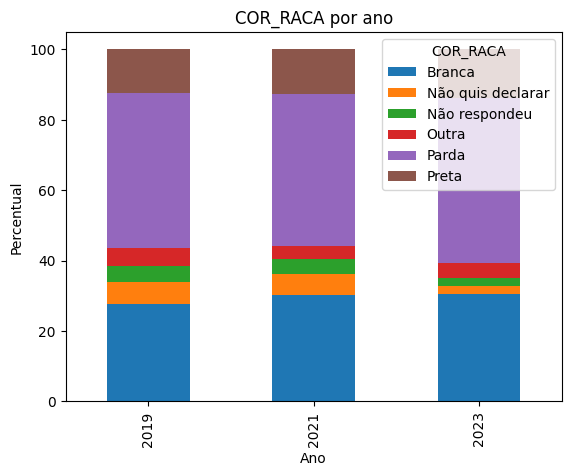

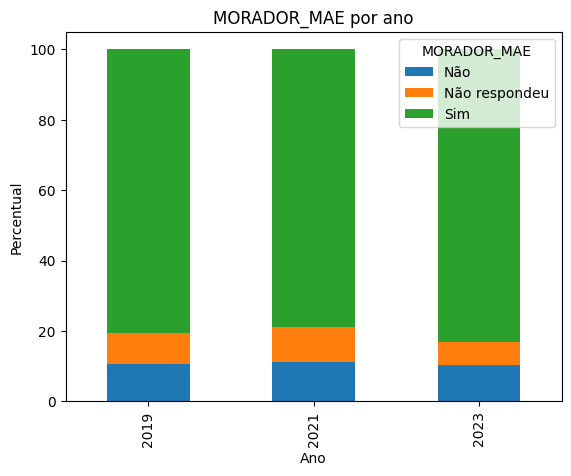

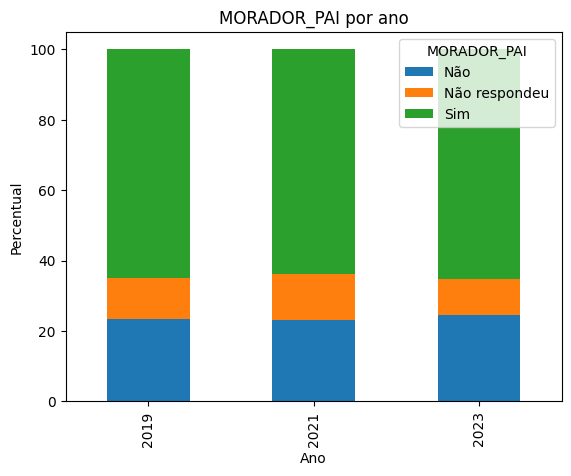

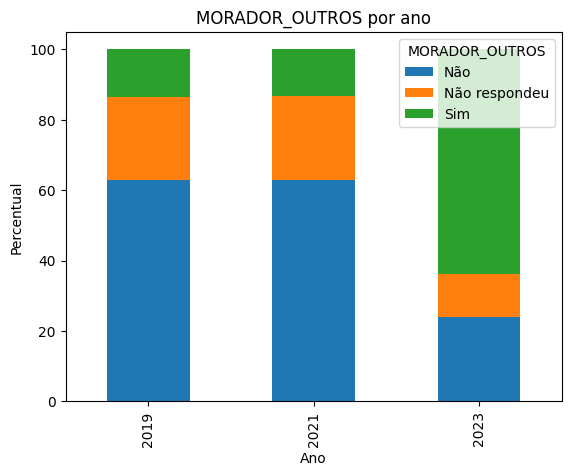

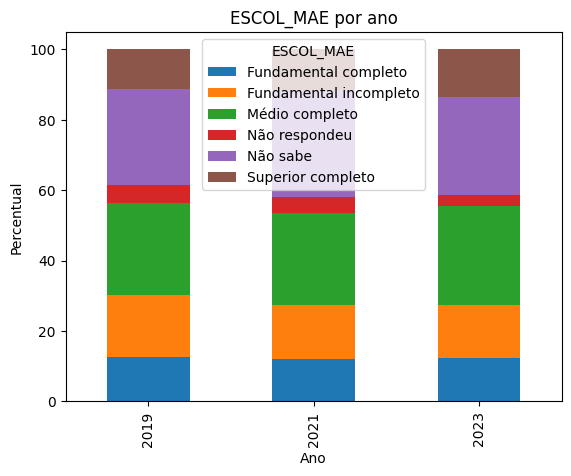

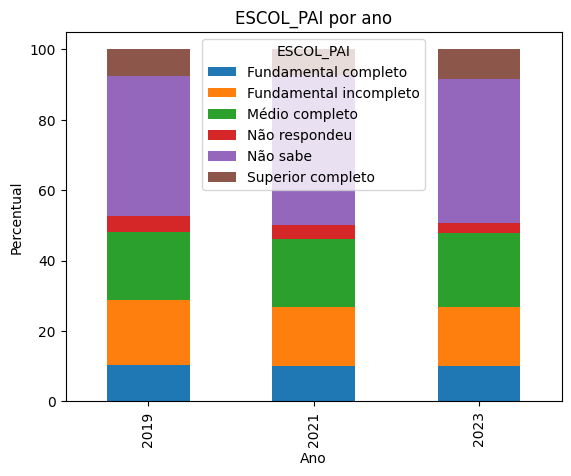

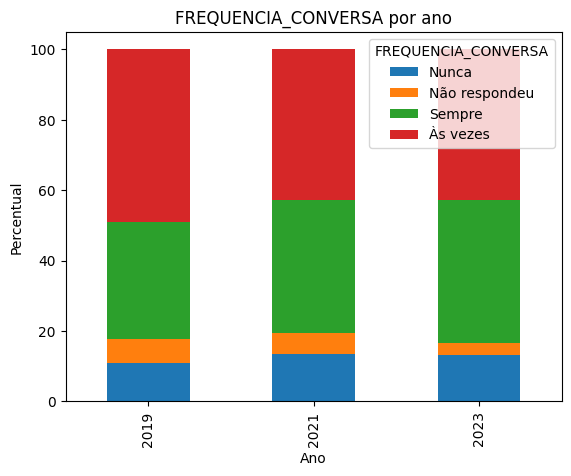

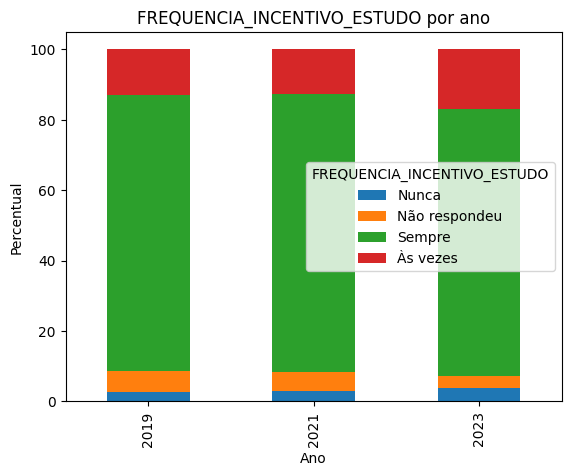

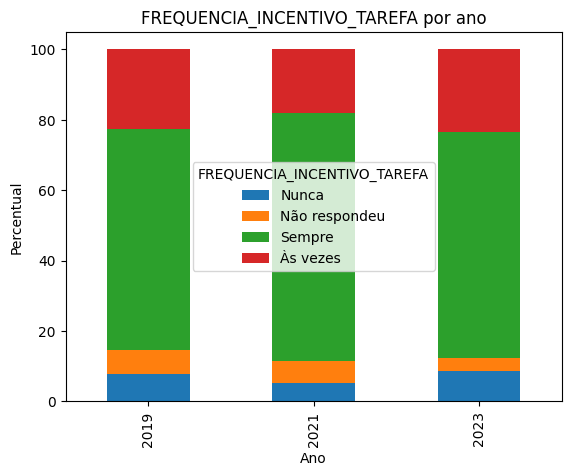

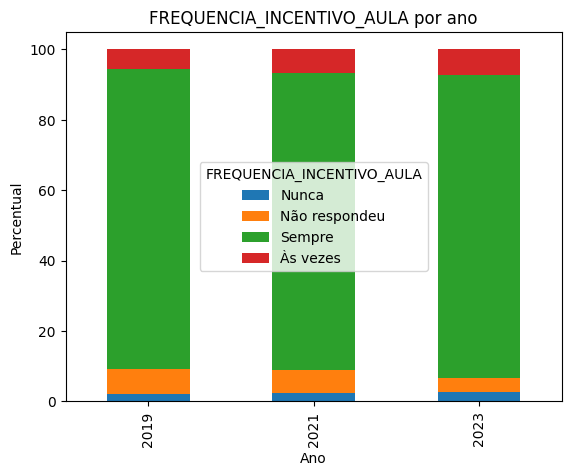

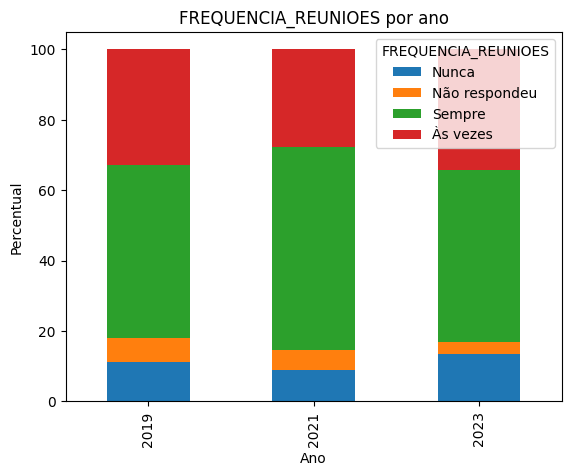

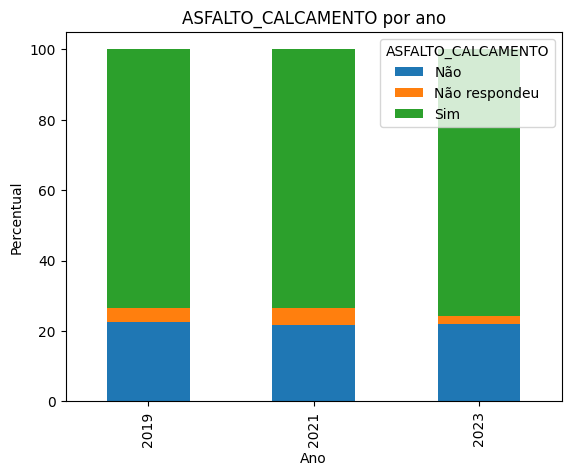

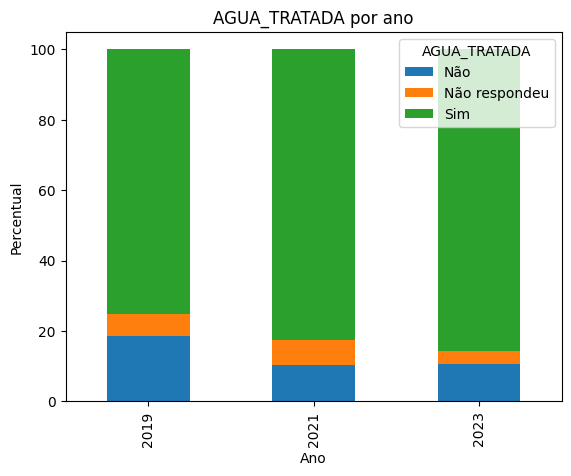

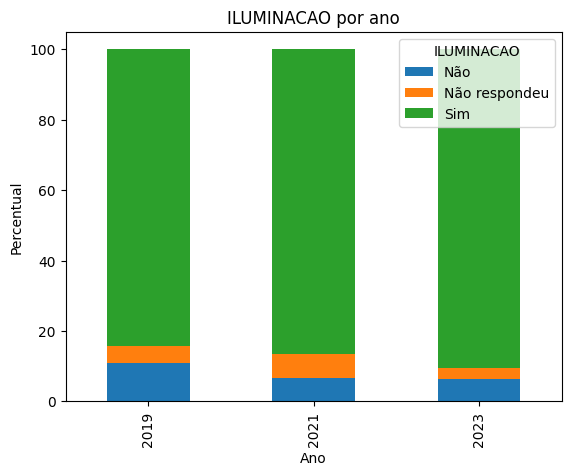

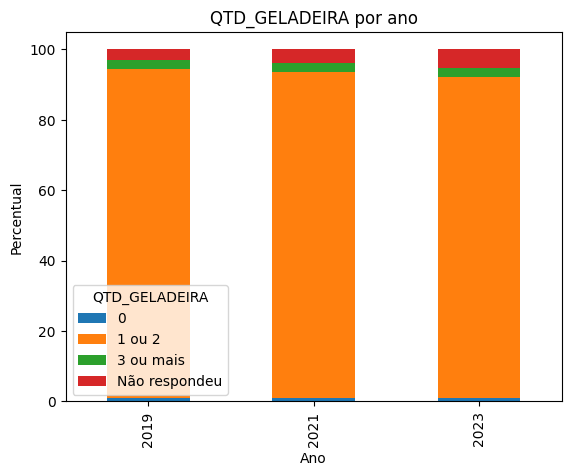

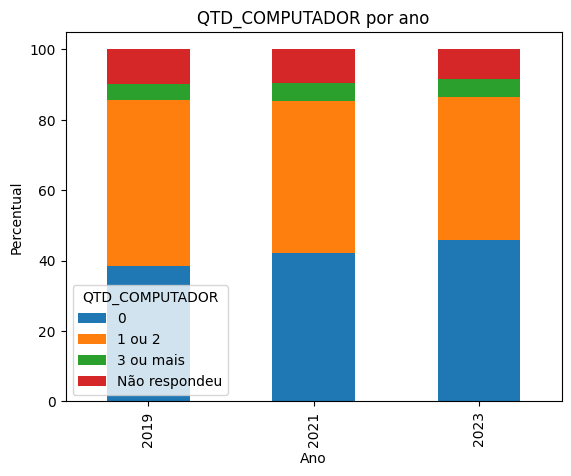

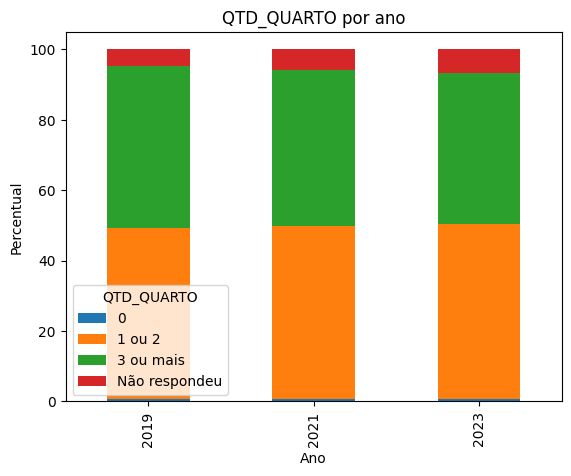

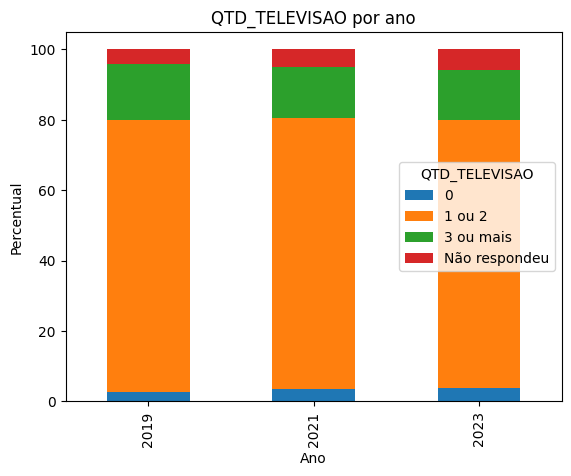

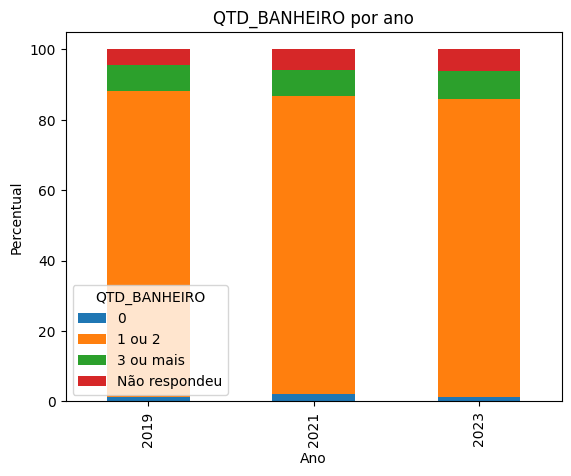

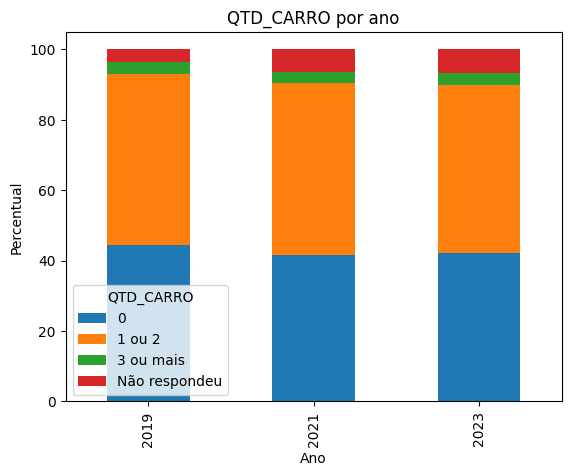

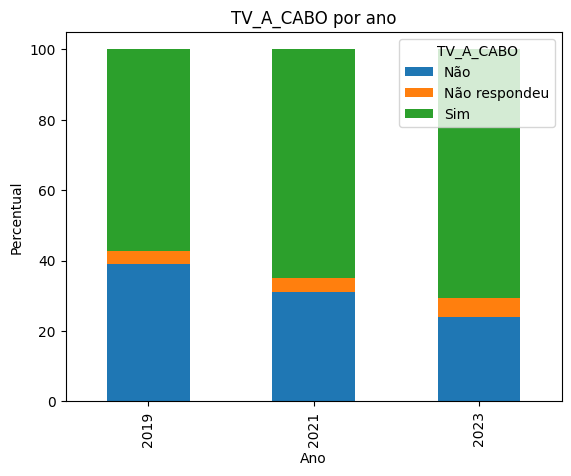

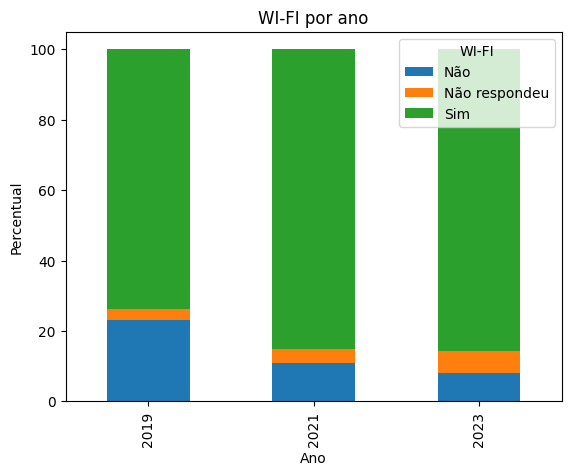

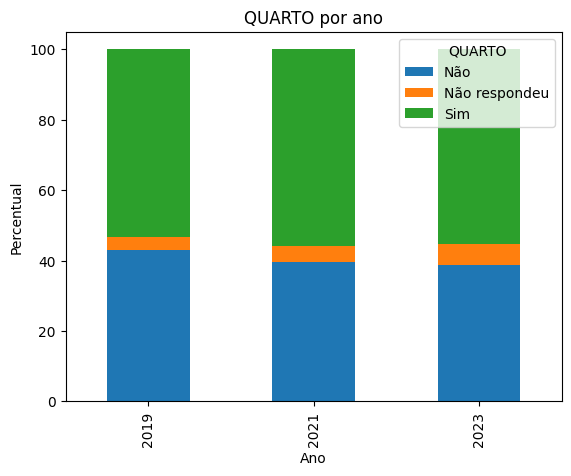

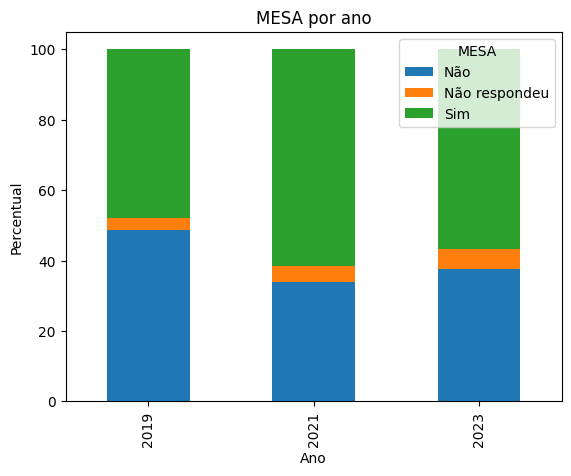

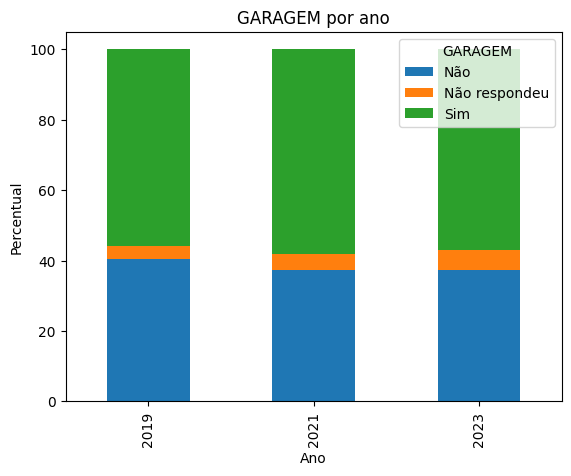

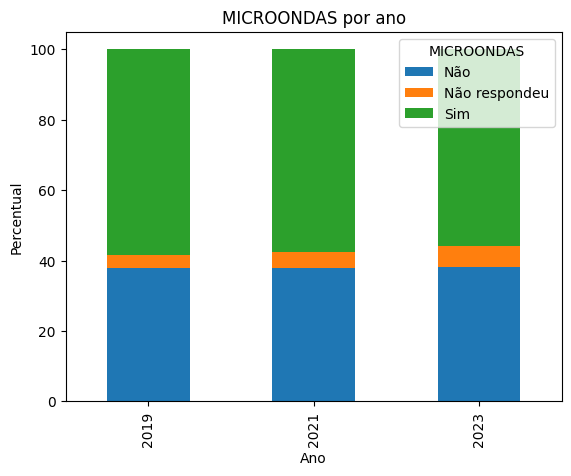

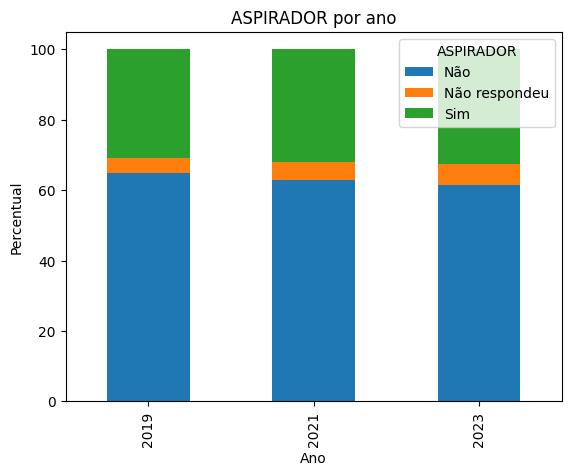

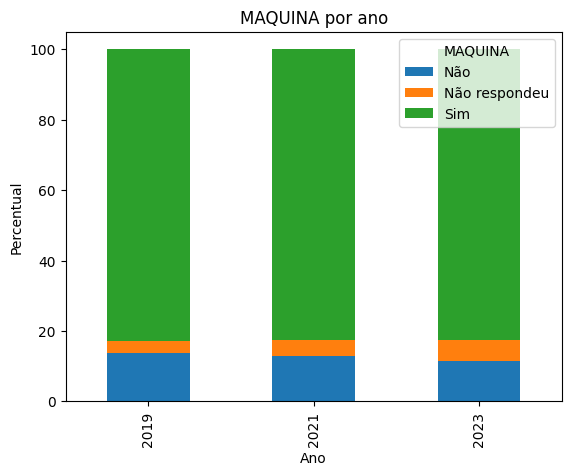

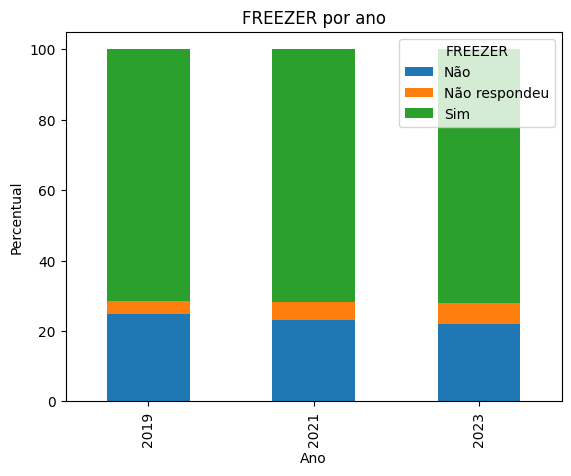

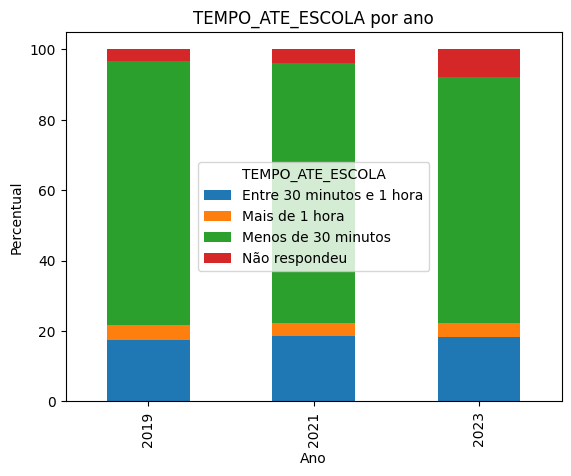

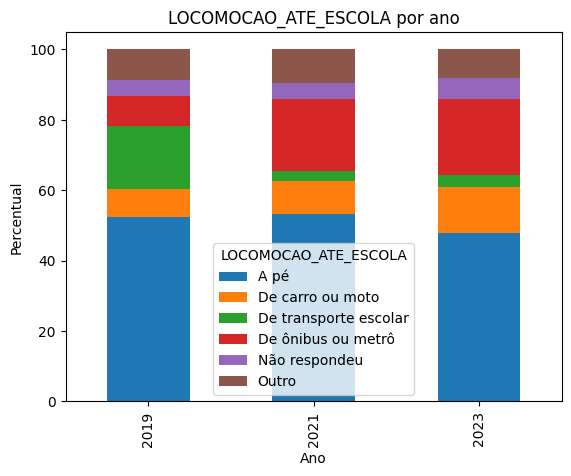

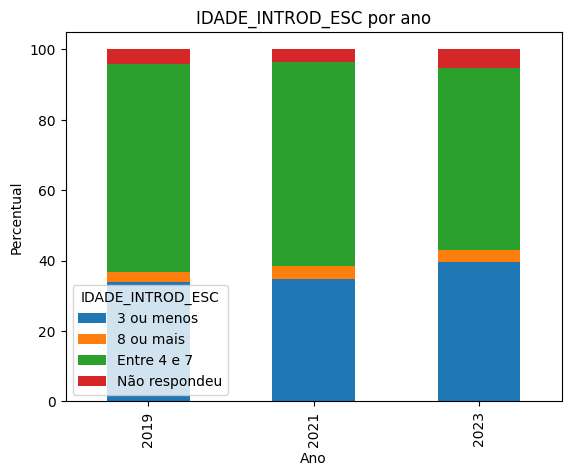

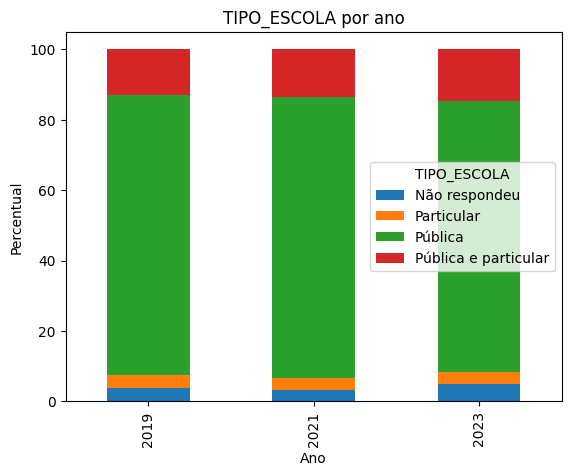

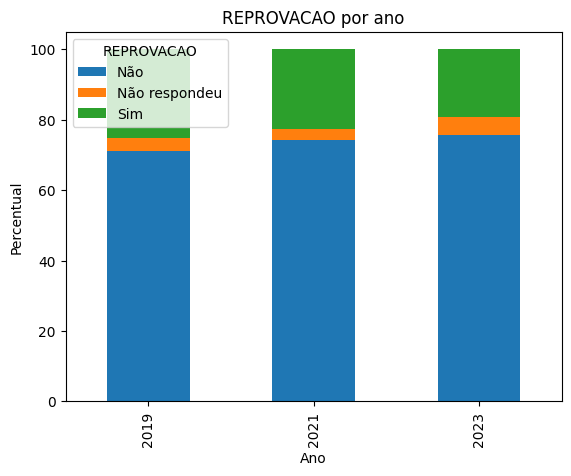

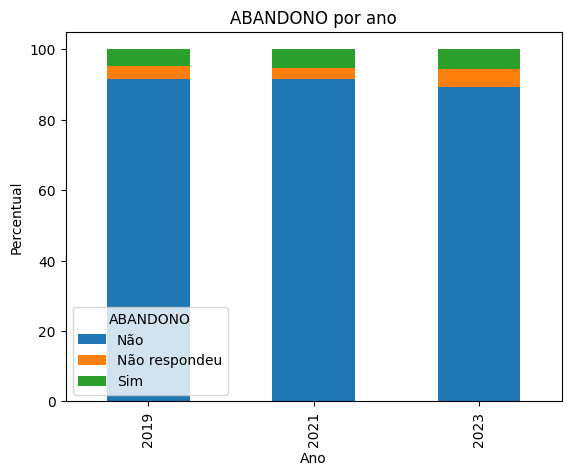

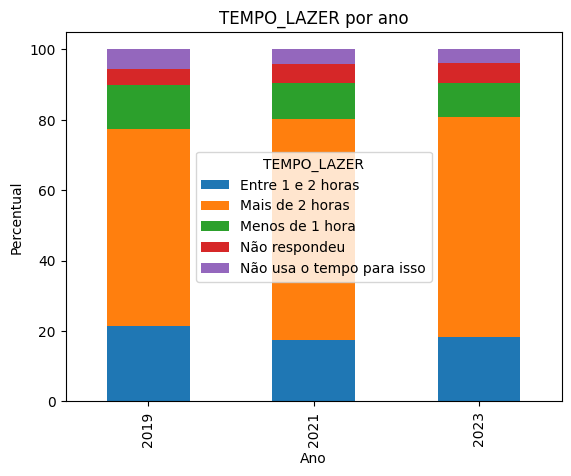

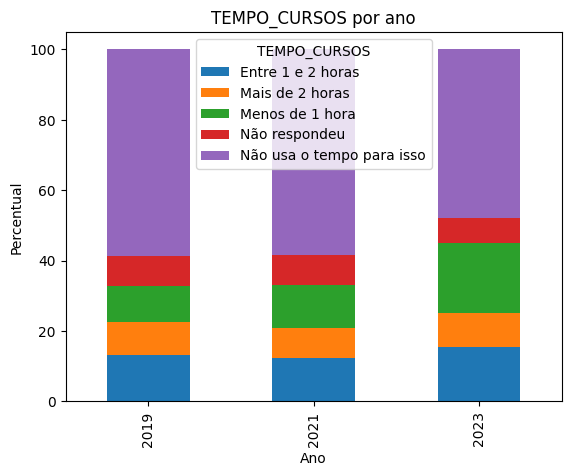

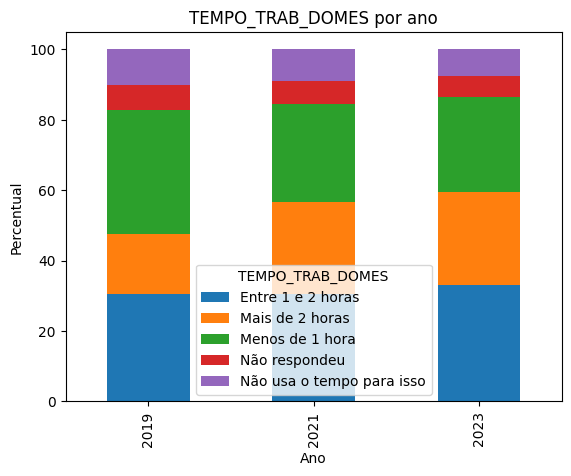

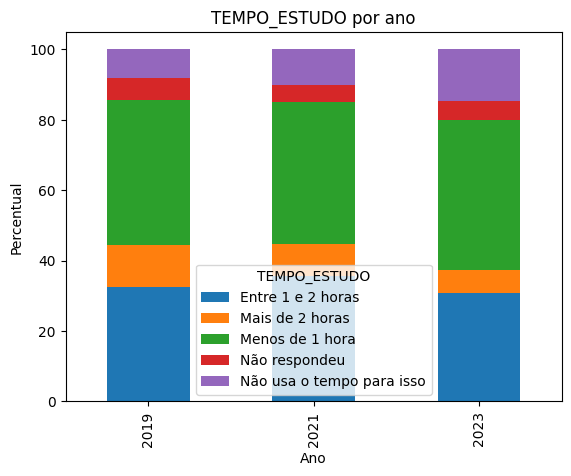

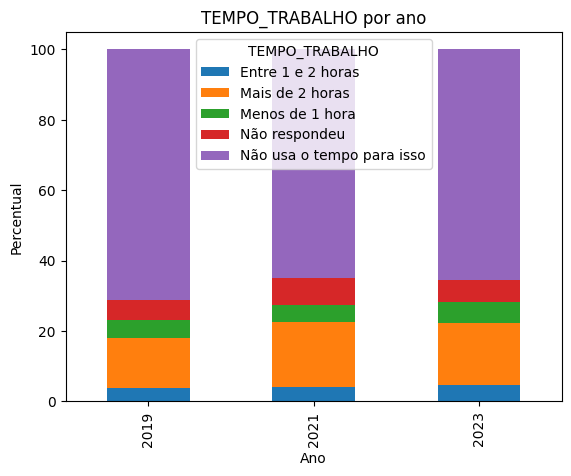

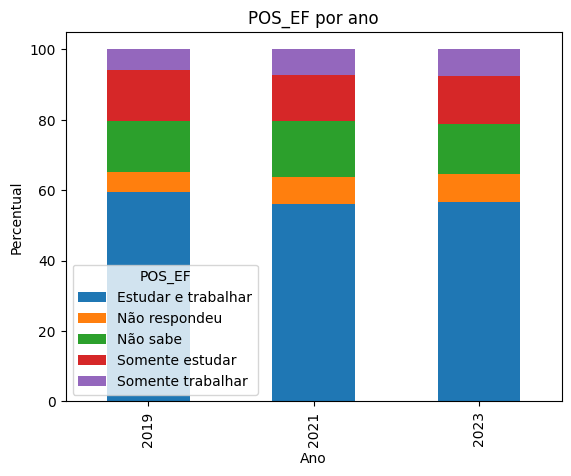

In [7]:
variaveis = [
    "LINGUA_FALADA","COR_RACA","MORADOR_MAE","MORADOR_PAI","MORADOR_OUTROS","ESCOL_MAE","ESCOL_PAI","FREQUENCIA_CONVERSA","FREQUENCIA_INCENTIVO_ESTUDO",
    "FREQUENCIA_INCENTIVO_TAREFA","FREQUENCIA_INCENTIVO_AULA","FREQUENCIA_REUNIOES","ASFALTO_CALCAMENTO","AGUA_TRATADA","ILUMINACAO","QTD_GELADEIRA",
    "QTD_COMPUTADOR","QTD_QUARTO","QTD_TELEVISAO","QTD_BANHEIRO","QTD_CARRO","TV_A_CABO","WI-FI","QUARTO","MESA","GARAGEM","MICROONDAS","ASPIRADOR",
    "MAQUINA","FREEZER","TEMPO_ATE_ESCOLA","LOCOMOCAO_ATE_ESCOLA","IDADE_INTROD_ESC","TIPO_ESCOLA","REPROVACAO","ABANDONO","TEMPO_LAZER","TEMPO_CURSOS",
    "TEMPO_TRAB_DOMES","TEMPO_ESTUDO","TEMPO_TRABALHO","POS_EF"
]
for var in variaveis:
    
    tabela = pd.crosstab(
        df_final["ANO"],
        df_final[var],
        normalize="index"
    ) * 100
    
    tabela.plot(kind="bar", stacked=True)

    plt.title(f"{var} por ano")
    plt.ylabel("Percentual")
    plt.xlabel("Ano")

    plt.show()

Entrando numa etapa mais analítica da pesquisa, agora o objetivo é comparar a evolução da proficiência para alguns aspectos em específico, levando em conta os resultados da análise de distribuição das variáveis relativos a esses aspectos.

#### 6. Proficiência por localização da escola

In [23]:
tab = df_final.groupby('LOCALIZACAO').agg({'PROFICIENCIA_SAEB': ['mean', 'median', 'std']})
tab

PROFICIENCIA_SAEB                       
                         mean      median        std
LOCALIZACAO                                         
1                  254.280280  255.396109  48.896862
2                  239.761624  237.561370  49.803143

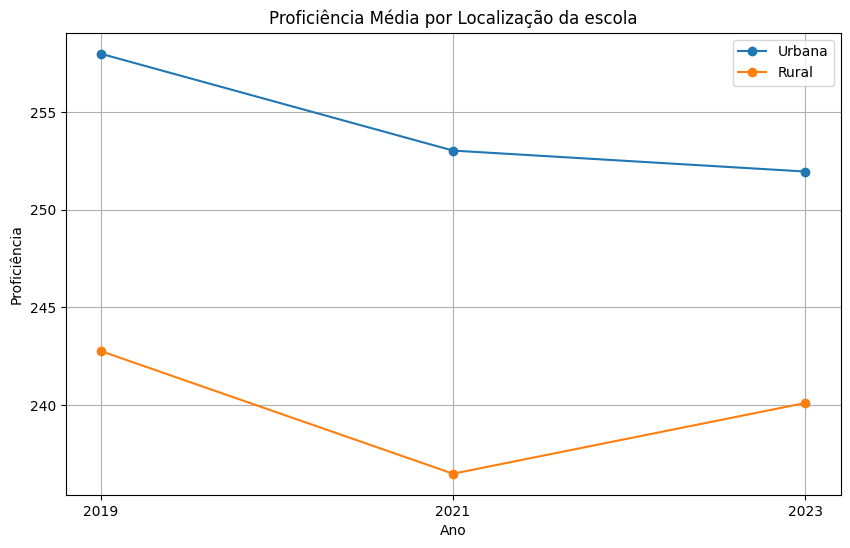

In [24]:
media_local = (
    df_final.groupby(["ANO", "LOCALIZACAO"])["PROFICIENCIA_SAEB"]
    .mean()
    .unstack()
)
media_local.plot(
    kind="line",
    marker="o",
    figsize=(10,6)
)
plt.xticks(media_local.index)
plt.legend([
    "Urbana",
    "Rural"
])
plt.title("Proficiência Média por Localização da escola")
plt.xlabel("Ano")
plt.ylabel("Proficiência")

plt.grid(True)

plt.show()

#### 7. Proficiência por cor/raça

In [20]:
tab = df_final.groupby('COR_RACA').agg({'PROFICIENCIA_SAEB': ['mean', 'median', 'std']})
tab

PROFICIENCIA_SAEB                       
                               mean      median        std
COR_RACA                                                  
Branca                   263.740217  266.490569  49.589905
Não quis declarar        241.911883  241.595958  48.885202
Não respondeu            239.923618  240.444129  49.194633
Outra                    244.708577  244.758710  48.525726
Parda                    251.867403  252.199431  48.008757
Preta                    240.510663  240.075324  47.257835

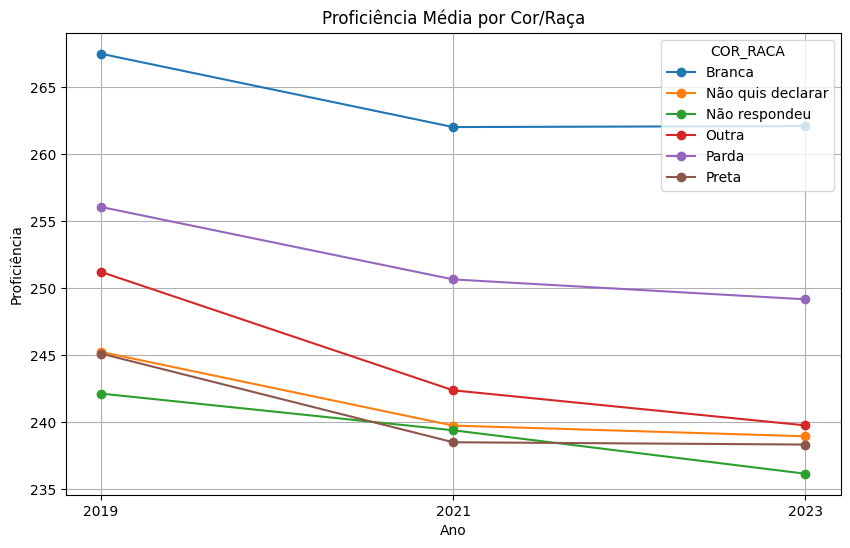

In [21]:
media_cor = (
    df_final.groupby(["ANO", "COR_RACA"])["PROFICIENCIA_SAEB"]
    .mean()
    .unstack()
)
media_cor.plot(
    kind="line",
    marker="o",
    figsize=(10,6)
)
plt.xticks(media_cor.index)
plt.title("Proficiência Média por Cor/Raça")
plt.xlabel("Ano")
plt.ylabel("Proficiência")

plt.grid(True)

plt.show()

#### 8. Proficiência por escolaridade da mãe 

In [22]:
tab = df_final.groupby('ESCOL_MAE').agg({'PROFICIENCIA_SAEB': ['mean', 'median', 'std']})
tab

PROFICIENCIA_SAEB                       
                                    mean      median        std
ESCOL_MAE                                                      
Fundamental completo          252.868805  254.224662  48.402963
Fundamental incompleto        243.542647  242.783838  48.044786
Médio completo                262.312904  264.476600  48.080573
Não respondeu                 238.686936  239.109141  48.576525
Não sabe                      243.287813  242.825645  47.217122
Superior completo             270.035553  273.069654  49.695138

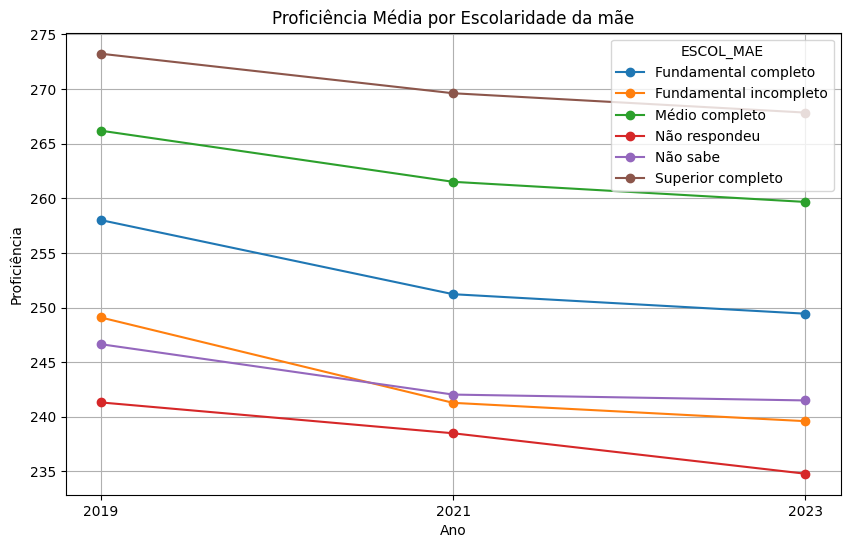

In [10]:
media_escol = (
    df_final.groupby(["ANO", "ESCOL_MAE"])["PROFICIENCIA_SAEB"]
    .mean()
    .unstack()
)
media_escol.plot(
    kind="line",
    marker="o",
    figsize=(10,6)
)
plt.xticks(media_escol.index)
plt.title("Proficiência Média por Escolaridade da mãe")
plt.xlabel("Ano")
plt.ylabel("Proficiência")

plt.grid(True)

plt.show()

#### 9. Proficiência por frequêcia de conversa (sobre o que acontece na escola)

In [25]:
tab = df_final.groupby('FREQUENCIA_CONVERSA').agg({'PROFICIENCIA_SAEB': ['mean', 'median', 'std']})
tab

PROFICIENCIA_SAEB                       
                                 mean      median        std
FREQUENCIA_CONVERSA                                         
Nunca                      248.385579  248.802324  49.450004
Não respondeu              222.213301  218.561500  47.959256
Sempre                     255.379463  256.111419  49.367518
Às vezes                   255.267137  256.269874  47.832429

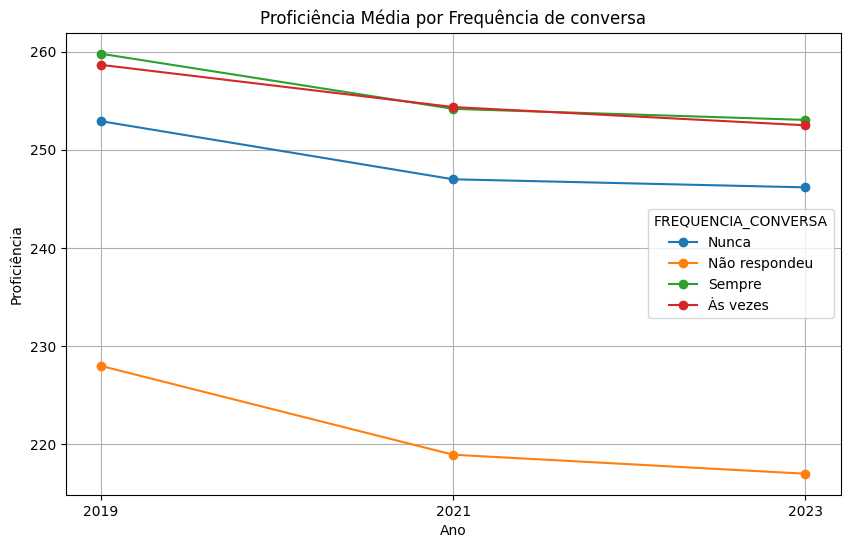

In [11]:
media_freq = (
    df_final.groupby(["ANO", "FREQUENCIA_CONVERSA"])["PROFICIENCIA_SAEB"]
    .mean()
    .unstack()
)
media_freq.plot(
    kind="line",
    marker="o",
    figsize=(10,6)
)
plt.xticks(media_freq.index)
plt.title("Proficiência Média por Frequência de conversa")
plt.xlabel("Ano")
plt.ylabel("Proficiência")

plt.grid(True)

plt.show()

#### 10. Proficiência por quantidade de computador

In [26]:
tab = df_final.groupby('QTD_COMPUTADOR').agg({'PROFICIENCIA_SAEB': ['mean', 'median', 'std']})
tab

PROFICIENCIA_SAEB                       
                            mean      median        std
QTD_COMPUTADOR                                         
0                     245.464834  244.991976  47.008513
1 ou 2                262.791601  265.172124  48.378467
3 ou mais             264.347956  267.651564  52.948317
Não respondeu         231.737587  230.246154  48.326604

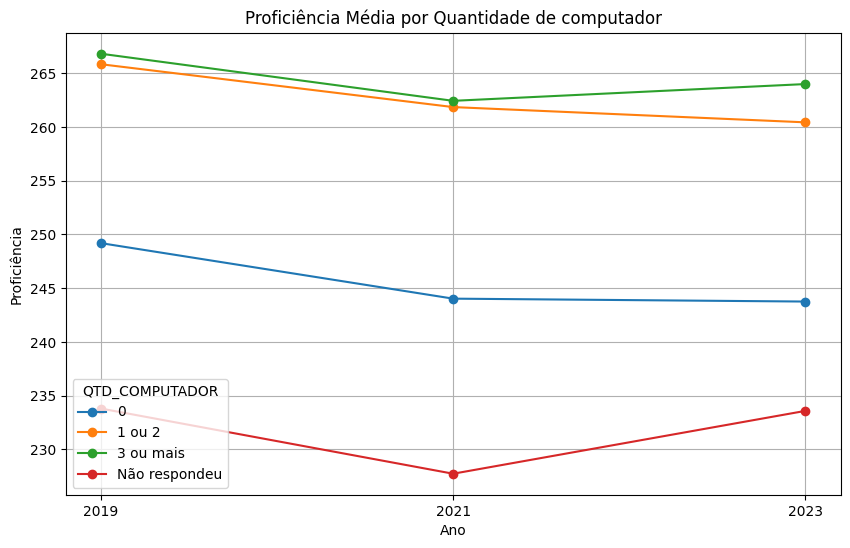

In [12]:
media_comput = (
    df_final.groupby(["ANO", "QTD_COMPUTADOR"])["PROFICIENCIA_SAEB"]
    .mean()
    .unstack()
)
media_comput.plot(
    kind="line",
    marker="o",
    figsize=(10,6)
)
plt.xticks(media_comput.index)
plt.title("Proficiência Média por Quantidade de computador")
plt.xlabel("Ano")
plt.ylabel("Proficiência")

plt.grid(True)

plt.show()

#### 11. Proficiência por quantidade de carro

In [27]:
tab = df_final.groupby('QTD_CARRO').agg({'PROFICIENCIA_SAEB': ['mean', 'median', 'std']})
tab

PROFICIENCIA_SAEB                       
                           mean      median        std
QTD_CARRO                                             
0                    246.397209  245.928843  47.423943
1 ou 2               261.021102  263.063922  48.678782
3 ou mais            255.840494  258.873813  50.979968
Não respondeu        226.669980  223.557296  50.031443

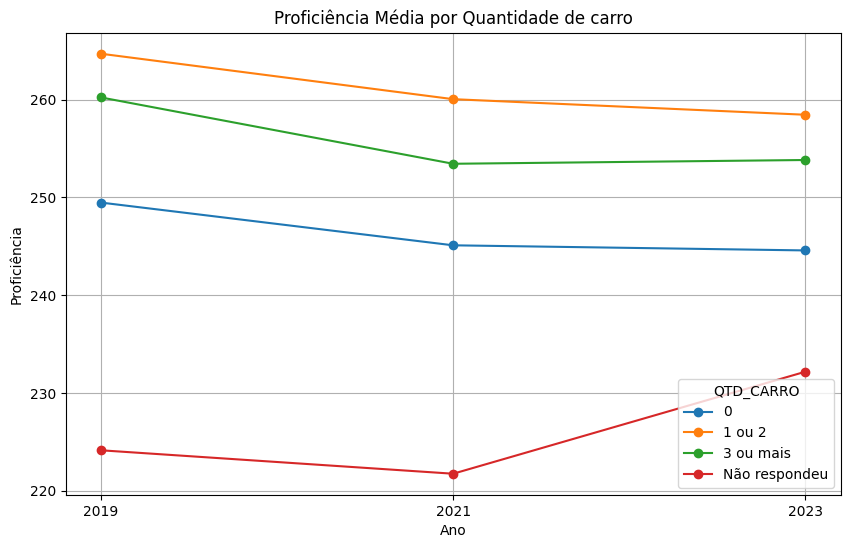

In [13]:
media_carro = (
    df_final.groupby(["ANO", "QTD_CARRO"])["PROFICIENCIA_SAEB"]
    .mean()
    .unstack()
)
media_carro.plot(
    kind="line",
    marker="o",
    figsize=(10,6)
)
plt.xticks(media_carro.index)
plt.title("Proficiência Média por Quantidade de carro")
plt.xlabel("Ano")
plt.ylabel("Proficiência")

plt.grid(True)

plt.show()

#### 12. Proficiência por possuimento de garagem

In [28]:
tab = df_final.groupby('GARAGEM').agg({'PROFICIENCIA_SAEB': ['mean', 'median', 'std']})
tab

PROFICIENCIA_SAEB                       
                           mean      median        std
GARAGEM                                               
Não                  246.100462  245.531393  47.798243
Não respondeu        226.647413  223.395348  50.795730
Sim                  259.244673  261.065380  48.714402

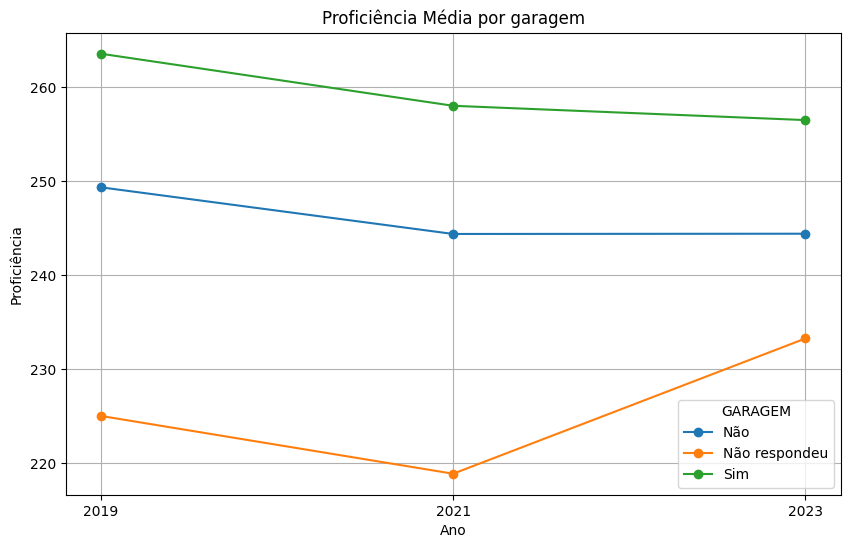

In [14]:
media_garagem = (
    df_final.groupby(["ANO", "GARAGEM"])["PROFICIENCIA_SAEB"]
    .mean()
    .unstack()
)
media_garagem.plot(
    kind="line",
    marker="o",
    figsize=(10,6)
)
plt.xticks(media_garagem.index)
plt.title("Proficiência Média por garagem")
plt.xlabel("Ano")
plt.ylabel("Proficiência")

plt.grid(True)

plt.show()

#### 13. Proficiência por idade de introdução escolar

In [29]:
tab = df_final.groupby('IDADE_INTROD_ESC').agg({'PROFICIENCIA_SAEB': ['mean', 'median', 'std']})
tab

PROFICIENCIA_SAEB                       
                              mean      median        std
IDADE_INTROD_ESC                                         
3 ou menos              253.040977  253.328400  49.890350
8 ou mais               228.915184  226.664770  47.307585
Entre 4 e 7             254.824430  256.042728  48.276283
Não respondeu           240.823915  240.994641  50.261736

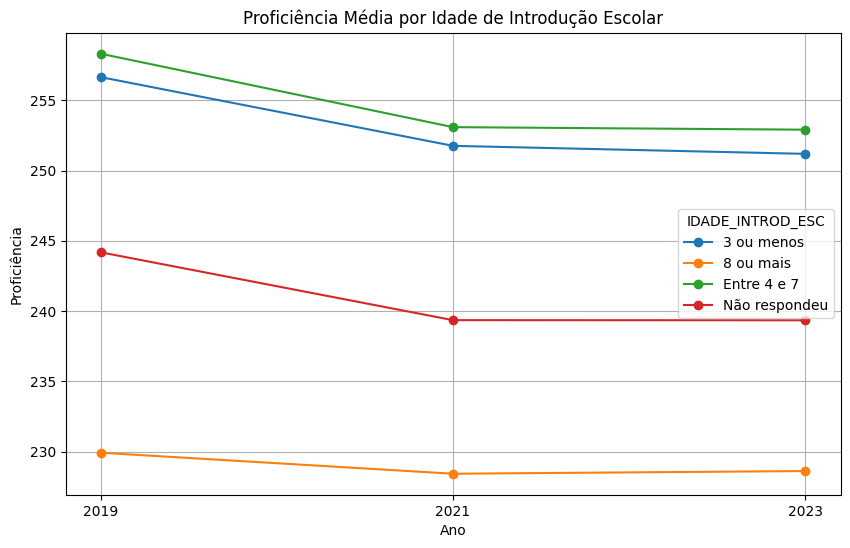

In [15]:
media_idade = (
    df_final.groupby(["ANO", "IDADE_INTROD_ESC"])["PROFICIENCIA_SAEB"]
    .mean()
    .unstack()
)
media_idade.plot(
    kind="line",
    marker="o",
    figsize=(10,6)
)
plt.xticks(media_idade.index)
plt.title("Proficiência Média por Idade de Introdução Escolar")
plt.xlabel("Ano")
plt.ylabel("Proficiência")

plt.grid(True)

plt.show()

#### 14. Proficiência por reprovação

In [31]:
tab = df_final.groupby('REPROVACAO').agg({'PROFICIENCIA_SAEB': ['mean', 'median', 'std']})
tab

PROFICIENCIA_SAEB                       
                           mean      median        std
REPROVACAO                                            
Não                  260.333832  261.913769  48.163096
Não respondeu        238.490258  238.294119  50.392860
Sim                  229.883994  228.682706  44.569953

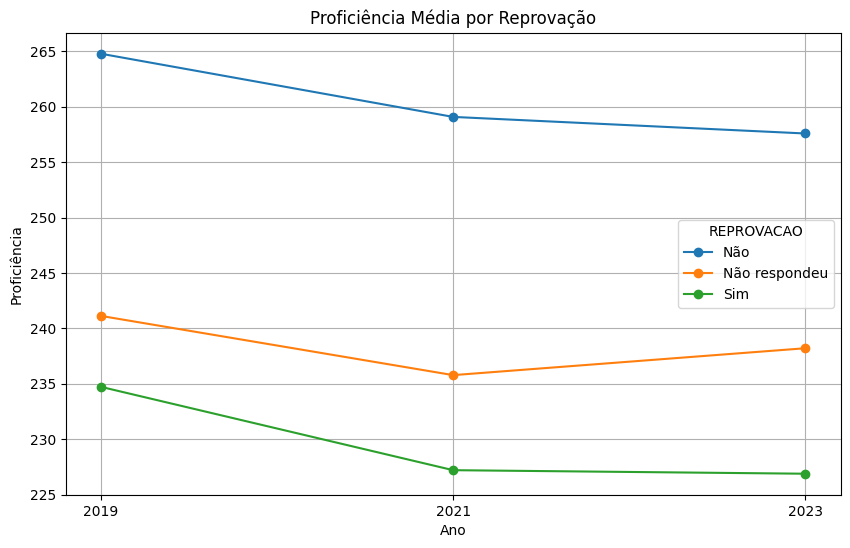

In [32]:
media_reprov = (
    df_final.groupby(["ANO", "REPROVACAO"])["PROFICIENCIA_SAEB"]
    .mean()
    .unstack()
)
media_reprov.plot(
    kind="line",
    marker="o",
    figsize=(10,6)
)
plt.xticks(media_reprov.index)
plt.title("Proficiência Média por Reprovação")
plt.xlabel("Ano")
plt.ylabel("Proficiência")

plt.grid(True)

plt.show()

#### 15. Proficiência por tempo gasto em trabaho doméstico

In [33]:
tab = df_final.groupby('TEMPO_TRAB_DOMES').agg({'PROFICIENCIA_SAEB': ['mean', 'median', 'std']})
tab

PROFICIENCIA_SAEB                       
                                       mean      median        std
TEMPO_TRAB_DOMES                                                  
Entre 1 e 2 horas                258.967697  260.234373  47.697548
Mais de 2 horas                  251.555893  251.962252  47.086477
Menos de 1 hora                  255.069263  255.898469  49.614671
Não respondeu                    231.021081  228.926453  50.318683
Não usa o tempo para isso        241.457345  240.238892  51.189582

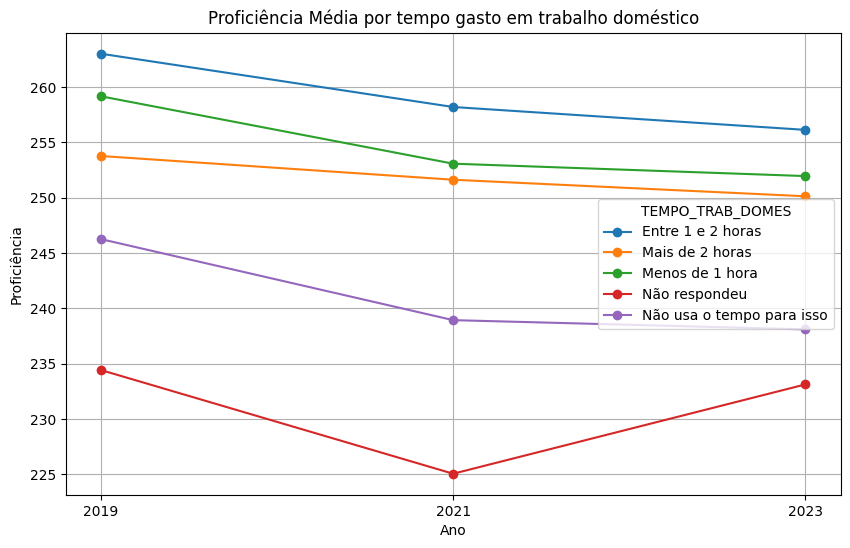

In [17]:
media_tempo_trab_dom = (
    df_final.groupby(["ANO", "TEMPO_TRAB_DOMES"])["PROFICIENCIA_SAEB"]
    .mean()
    .unstack()
)
media_tempo_trab_dom.plot(
    kind="line",
    marker="o",
    figsize=(10,6)
)
plt.xticks(media_tempo_trab_dom.index)
plt.title("Proficiência Média por tempo gasto em trabalho doméstico")
plt.xlabel("Ano")
plt.ylabel("Proficiência")

plt.grid(True)

plt.show()

#### 16. Proficiência por tempo gasto em estudo

In [34]:
tab = df_final.groupby('TEMPO_ESTUDO').agg({'PROFICIENCIA_SAEB': ['mean', 'median', 'std']})
tab

PROFICIENCIA_SAEB                       
                                       mean      median        std
TEMPO_ESTUDO                                                      
Entre 1 e 2 horas                260.950297  262.257703  47.528289
Mais de 2 horas                  251.869876  250.933722  52.352365
Menos de 1 hora                  252.688009  253.403687  47.691118
Não respondeu                    230.764140  228.530679  50.865525
Não usa o tempo para isso        239.476960  238.599794  49.980975

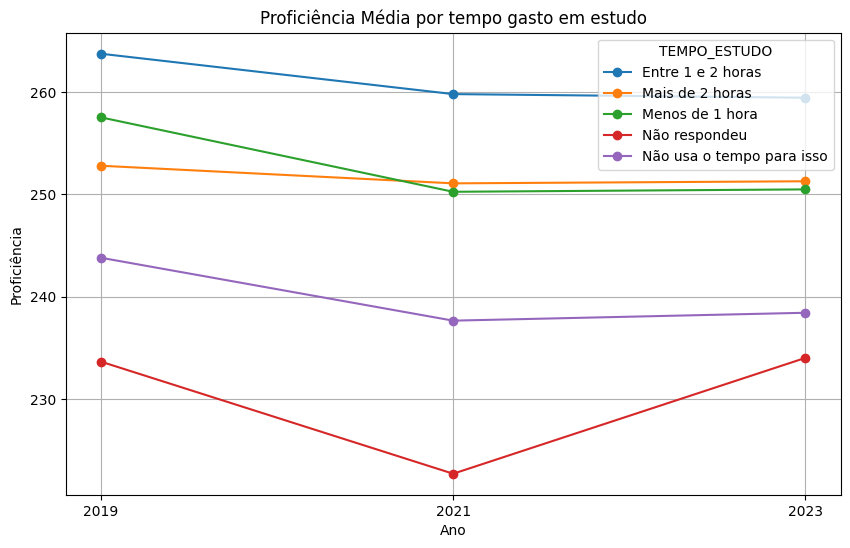

In [18]:
media_tempo_estudo = (
    df_final.groupby(["ANO", "TEMPO_ESTUDO"])["PROFICIENCIA_SAEB"]
    .mean()
    .unstack()
)
media_tempo_estudo.plot(
    kind="line",
    marker="o",
    figsize=(10,6)
)
plt.xticks(media_tempo_estudo.index)
plt.title("Proficiência Média por tempo gasto em estudo")
plt.xlabel("Ano")
plt.ylabel("Proficiência")

plt.grid(True)

plt.show()

#### 17. Proficiência por pretensão pós Ensino Fundamental

In [35]:
tab = df_final.groupby('POS_EF').agg({'PROFICIENCIA_SAEB': ['mean', 'median', 'std']})
tab

PROFICIENCIA_SAEB                       
                                 mean      median        std
POS_EF                                                      
Estudar e trabalhar        258.079717  259.503832  47.012662
Não respondeu              238.305569  237.605106  49.508849
Não sabe                   242.402867  241.508822  48.435441
Somente estudar            260.021704  261.357865  53.764717
Somente trabalhar          229.964688  228.649255  45.529986

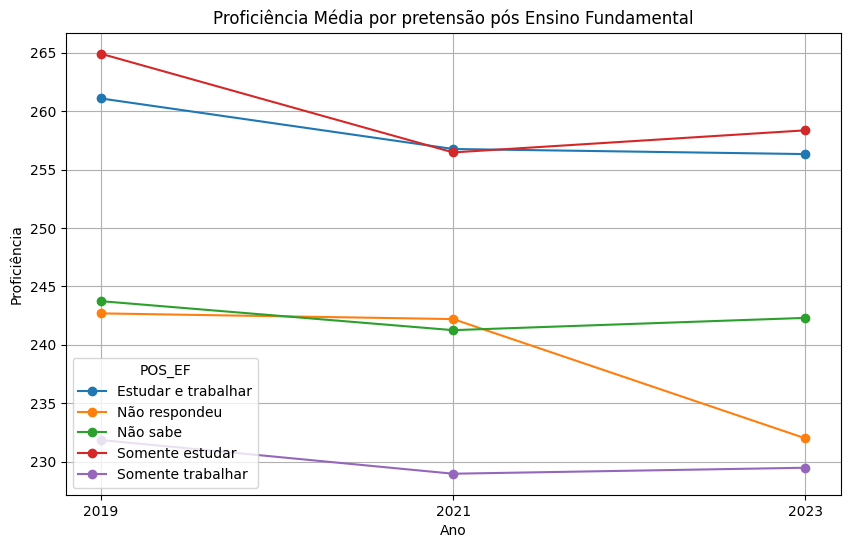

In [19]:
media_pos_ef = (
    df_final.groupby(["ANO", "POS_EF"])["PROFICIENCIA_SAEB"]
    .mean()
    .unstack()
)
media_pos_ef.plot(
    kind="line",
    marker="o",
    figsize=(10,6)
)
plt.xticks(media_pos_ef.index)
plt.title("Proficiência Média por pretensão pós Ensino Fundamental")
plt.xlabel("Ano")
plt.ylabel("Proficiência")

plt.grid(True)

plt.show()

Agora, serão feitas algumas análises adicionais consideradas relevantes em relação à variável 'SEXO', que só aparece nos datasets dos anos de 2021 e 2023.

#### 18. Proficiência por sexo